# Problem Statement

#### Turn a static EV specification dataset into a reproducible machine-learning solution that predicts vehicle range from specifications and can be tested on new user inputs.

# 1. Importing Dependencies

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import joblib

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

TARGET = "range_km"
LEAKAGE_COLUMN = "efficiency_wh_per_km"


ModuleNotFoundError: No module named 'seaborn'

# 2. Data Audit

In [ ]:
data_paths = [
    Path("raw(1).csv"), Path("raw.csv"),
    Path("../data/raw.csv"), Path("data/raw.csv"), Path("data/raw(1).csv"),
    Path("upload/raw(1).csv"), Path("../upload/raw(1).csv"),
]
DATA_PATH = next((path for path in data_paths if path.is_file()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place raw(1).csv or raw.csv beside the notebook.")


In [ ]:
data = pd.read_csv(DATA_PATH)
data.head()


,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      478 non-null    str    
 1   model                      477 non-null    str    
 2   top_speed_kmh              478 non-null    int64  
 3   battery_capacity_kWh       478 non-null    float64
 4   battery_type               478 non-null    str    
 5   number_of_cells            276 non-null    float64
 6   torque_nm                  471 non-null    float64
 7   efficiency_wh_per_km       478 non-null    int64  
 8   range_km                   478 non-null    int64  
 9   acceleration_0_100_s       478 non-null    float64
 10  fast_charging_power_kw_dc  477 non-null    float64
 11  fast_charge_port           477 non-null    str    
 12  towing_capacity_kg         452 non-null    float64
 13  cargo_volume_l             477 non-null    str    
 14  seats

In [ ]:
TARGET = 'range_km'

In [ ]:
col_not_to_use_for_modeling = [TARGET, 'efficiency_wh_per_km']

In [ ]:
numeric_columns = [
    "top_speed_kmh", "battery_capacity_kWh", "number_of_cells", "torque_nm",
    "acceleration_0_100_s", "fast_charging_power_kw_dc", "towing_capacity_kg",
    "cargo_volume_l", "seats", "length_mm", "width_mm", "height_mm",
]
categorical_columns = ["drivetrain", "segment", "car_body_type"]
raw_feature_columns = numeric_columns + categorical_columns

missing_columns = set(raw_feature_columns + [TARGET, "brand", "model"]) - set(data.columns)
if missing_columns:
    raise ValueError(f"Missing columns: {sorted(missing_columns)}")

num_col = data.select_dtypes(include=np.number).columns.drop(TARGET).tolist()
cat_col = data.select_dtypes(exclude=np.number).columns.tolist()


In [ ]:
print(f"Numerical Columns : \n {num_col}\n\n\nCategorical COlumns : \n{cat_col}\n\n\n\n Target : {TARGET}")

Numerical Columns : 
 ['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'seats', 'length_mm', 'width_mm', 'height_mm']


Categorical COlumns : 
['brand', 'model', 'battery_type', 'fast_charge_port', 'cargo_volume_l', 'drivetrain', 'segment', 'car_body_type', 'source_url']



 Target : range_km


#### Missing Value analysis

In [ ]:

missing_summary = (
    data.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(data) * 100).round(1)
missing_summary[missing_summary["missing_count"] > 0]


,missing_count,missing_pct
number_of_cells,202,42.3
towing_capacity_kg,26,5.4
torque_nm,7,1.5
fast_charging_power_kw_dc,1,0.2
fast_charge_port,1,0.2
model,1,0.2
cargo_volume_l,1,0.2


#### Duplicate Value Analysis

In [ ]:
print("Exact duplicate rows:", data.duplicated().sum())
print("Duplicate (brand, model) pairs:", data.duplicated(subset=["brand", "model"]).sum())


Exact duplicate rows: 0
Duplicate (brand, model) pairs: 0


#### Columns flagged in the problem statement as needing special handling

In [ ]:

print("battery_type unique values:", data["battery_type"].unique())
print('\n'*3)

print("fast_charge_port value counts:\n", data["fast_charge_port"].value_counts())
print('\n'*3)

non_numeric_cargo = data[pd.to_numeric(data["cargo_volume_l"], errors="coerce").isna()
                            & data["cargo_volume_l"].notna()]
print("Non-numeric cargo_volume_l entries:")
non_numeric_cargo[["brand", "model", "cargo_volume_l"]]


battery_type unique values: <StringArray>
['Lithium-ion']
Length: 1, dtype: str




fast_charge_port value counts:
 fast_charge_port
CCS        476
CHAdeMO      1
Name: count, dtype: int64




Non-numeric cargo_volume_l entries:


,brand,model,cargo_volume_l
29,Audi,Q6 e-tron quattro,10 Banana Boxes
213,Maxus,MIFA 9,31 Banana Boxes
246,Mercedes-Benz,EQS SUV 580 4MATIC,13 Banana Boxes


Data Audit Takeawyss:
- battery_type is constant → no variance, drop.
- fast_charge_port is almost entirely CCS (476/478) → near-zero variance, drop.
- source_url is metadata, not a specification → drop.
- number_of_cells is missing in ~42% of rows — keep it with a missingness flag.
- torque_nm, fast_charging_power_kw_dc and towing_capacity_kg contain missing values → impute inside the modelling pipeline.
- cargo_volume_l contains 3 entries recorded as **"N Banana Boxes"** instead of litres. These are kept as missing litre values with a separate flag; no unit conversion is assumed.
- No exact duplicate rows.



# 3. Data Cleaning

Every transformation below is justified by the profiling step above.


In [ ]:
def clean_specifications(frame):
    cleaned = frame.copy()
    cargo_text = cleaned["cargo_volume_l"].astype("string").str.strip()
    cargo_unknown = cargo_text.str.fullmatch(
        r"(?i)\d+(?:\.\d+)?\s+banana\s+box(?:es)?", na=False
    )

    for column in numeric_columns:
        values = cleaned[column].astype("string").str.strip()
        values = values.mask(values.str.casefold().isin(["", "na", "n/a", "nan", "none", "null"]))
        if column == "cargo_volume_l":
            values = values.mask(cargo_unknown)
        numeric = pd.Series(
            pd.to_numeric(values, errors="coerce").to_numpy(dtype=float, na_value=np.nan),
            index=cleaned.index,
        )
        if (values.notna() & numeric.isna()).any():
            raise ValueError(f"Invalid numeric values in {column}")
        invalid = numeric.notna() & (~np.isfinite(numeric) | numeric.lt(0))
        if column not in ["towing_capacity_kg", "cargo_volume_l", "fast_charging_power_kw_dc"]:
            invalid = invalid | numeric.eq(0)
        if column in ["seats", "number_of_cells"]:
            invalid = invalid | (numeric.notna() & numeric.ne(np.floor(numeric)))
        if invalid.any():
            raise ValueError(f"Invalid values or units in {column}")
        cleaned[column] = numeric

    for column in categorical_columns:
        values = cleaned[column].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)
        values = values.mask(values.str.casefold().isin(["", "na", "n/a", "nan", "none", "null"]))
        values = values.str.upper() if column == "drivetrain" else values.str.casefold()
        cleaned[column] = values.astype(object).where(values.notna(), np.nan)

    cleaned["cells_missing_flag"] = cleaned["number_of_cells"].isna().astype(int)
    cleaned["cargo_missing_flag"] = cleaned["cargo_volume_l"].isna().astype(int)
    cleaned["cargo_unknown_unit_flag"] = cargo_unknown.astype(int)
    return cleaned


df = data.copy()
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows")

target_values = pd.to_numeric(df[TARGET], errors="coerce")
invalid_target = df[TARGET].notna() & (
    target_values.isna() | ~np.isfinite(target_values) | target_values.le(0)
)
if invalid_target.any():
    raise ValueError("range_km contains invalid target values.")
print("Rows without a target:", target_values.isna().sum())
df = df.loc[target_values.notna()].copy()
df[TARGET] = target_values.loc[df.index]
raw_df = df.copy()

df = clean_specifications(df)
df["model"] = df["model"].fillna("Unknown")
df = df.drop(columns=["battery_type", "fast_charge_port", "source_url"], errors="ignore")

print(f"Shape after cleaning: {df.shape}")
df.isna().sum()[df.isna().sum() > 0]


Dropped 0 exact duplicate rows
Rows without a target: 0
Shape after cleaning: (478, 22)


number_of_cells              202
torque_nm                      7
fast_charging_power_kw_dc      1
towing_capacity_kg            26
cargo_volume_l                 4
dtype: int64

Remaining missing values are handled by **median imputation inside the modelling
pipeline**, not here. Imputation, scaling and encoding are fit on the training
fold only, so information from the validation or test rows is not used.


# 4. Exploratory Data Analysis

EDA here is targeted at what the target looks like, which specifications move
together, and how categorical variables relate to range. The test groups are
set aside first; all plots below use training rows only.


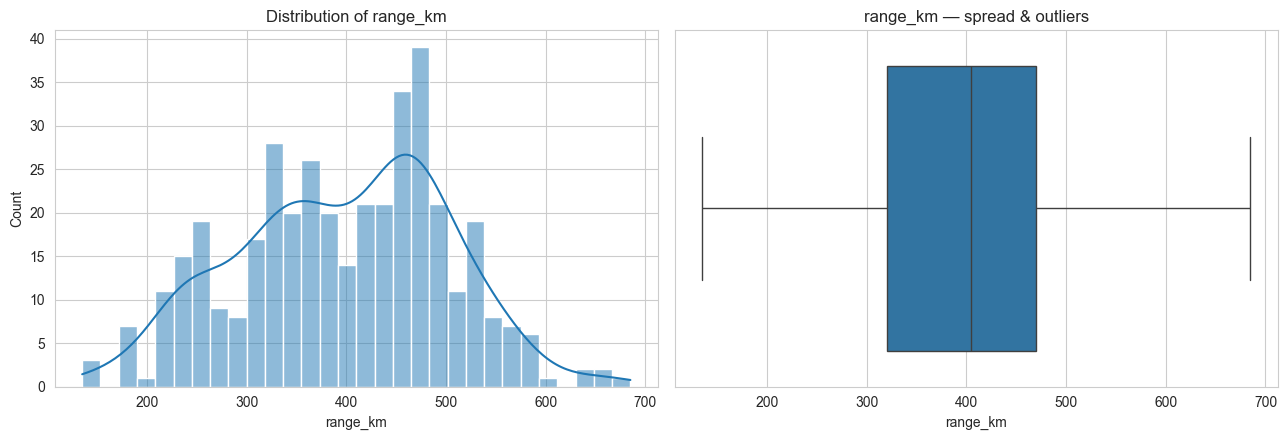

count    391.000000
mean     396.253197
std      104.905769
min      135.000000
25%      320.000000
50%      405.000000
75%      470.000000
max      685.000000
Name: range_km, dtype: float64


In [ ]:
model_family = df["model"].str.strip().str.casefold().str.split().str[0].fillna("unknown")
groups = df["brand"].fillna("Unknown").str.strip().str.casefold() + "::" + model_family

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
train_positions, test_positions = next(splitter.split(df, groups=groups))
train_index = df.index[train_positions]
test_index = df.index[test_positions]
assert set(groups.loc[train_index]).isdisjoint(set(groups.loc[test_index]))
eda_df = df.loc[train_index].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(eda_df[TARGET], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of range_km")
sns.boxplot(x=eda_df[TARGET], ax=axes[1])
axes[1].set_title("range_km — spread & outliers")
plt.tight_layout()
plt.show()

print(eda_df[TARGET].describe())


The distribution and boxplot show the spread of `range_km` in the training set.
No statistical outlier removal is applied; invalid targets are checked during
cleaning.


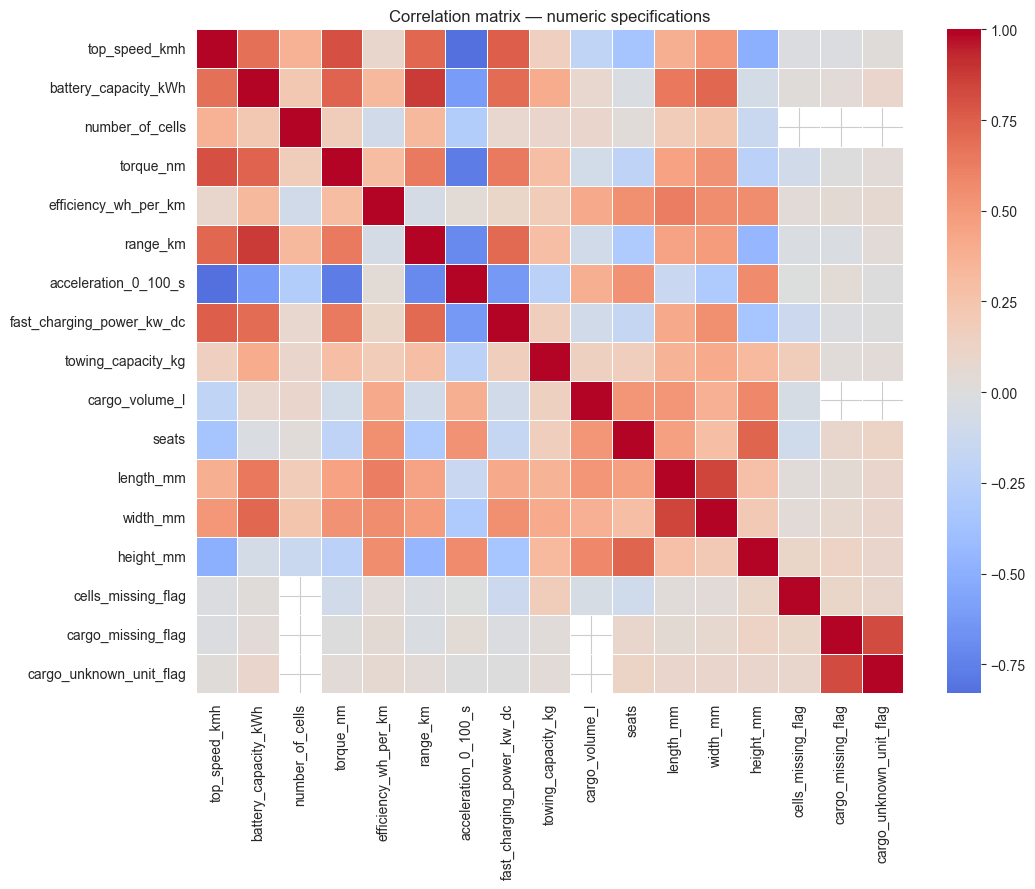

range_km                     1.000000
battery_capacity_kWh         0.871880
top_speed_kmh                0.717042
fast_charging_power_kw_dc    0.712125
torque_nm                    0.636681
width_mm                     0.492411
length_mm                    0.444532
number_of_cells              0.322640
towing_capacity_kg           0.288458
cargo_unknown_unit_flag      0.035072
cells_missing_flag          -0.026166
cargo_missing_flag          -0.026230
efficiency_wh_per_km        -0.057763
cargo_volume_l              -0.089190
seats                       -0.295851
height_mm                   -0.446640
acceleration_0_100_s        -0.702222
Name: range_km, dtype: float64

In [ ]:
numeric_cols_for_corr = eda_df.select_dtypes(include=[np.number]).columns.tolist()
corr = eda_df[numeric_cols_for_corr].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.4)
plt.title("Correlation matrix — numeric specifications")
plt.tight_layout()
plt.show()

corr[TARGET].sort_values(ascending=False)


`battery_capacity_kWh` is kept as a specification input.
`efficiency_wh_per_km` is excluded: range, battery capacity and efficiency can
be linked (`range ≈ battery_capacity / efficiency × 1000`), so this field may
encode information about the target. Correlation alone does not prove leakage.


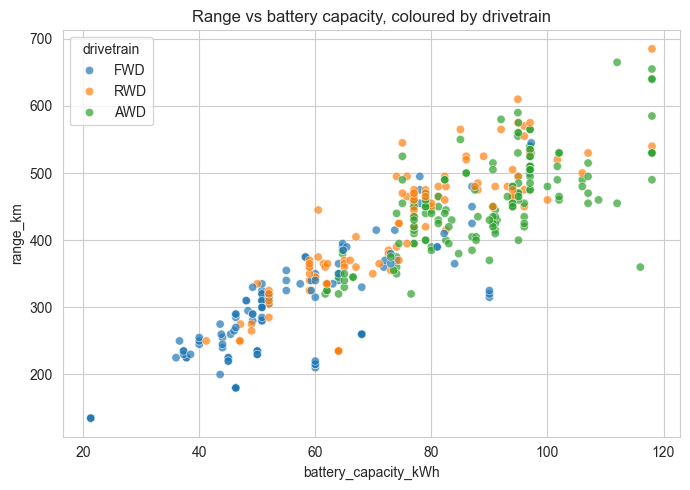

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=eda_df, x="battery_capacity_kWh", y=TARGET, hue="drivetrain", alpha=0.7)
plt.title("Range vs battery capacity, coloured by drivetrain")
plt.tight_layout()
plt.show()


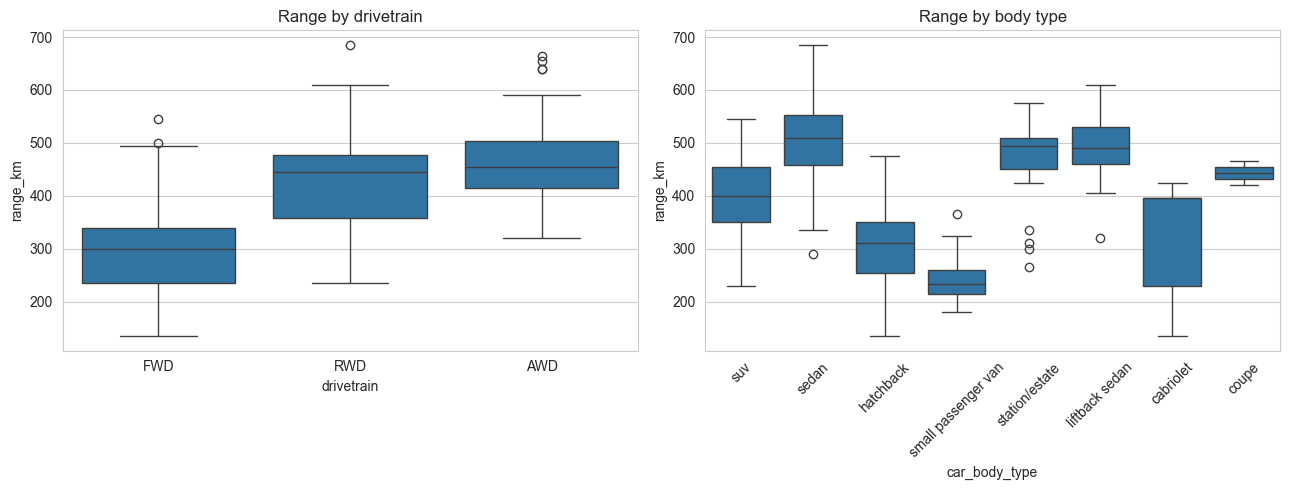

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=eda_df, x="drivetrain", y=TARGET, ax=axes[0])
axes[0].set_title("Range by drivetrain")

top_body_types = eda_df["car_body_type"].value_counts().index
sns.boxplot(data=eda_df, x="car_body_type", y=TARGET, order=top_body_types, ax=axes[1])
axes[1].set_title("Range by body type")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


- **Drivetrain**: compare the median range and spread across FWD, RWD and AWD.
- **Body type**: compare the range distributions across body styles. Both
  variables are kept as categorical features.


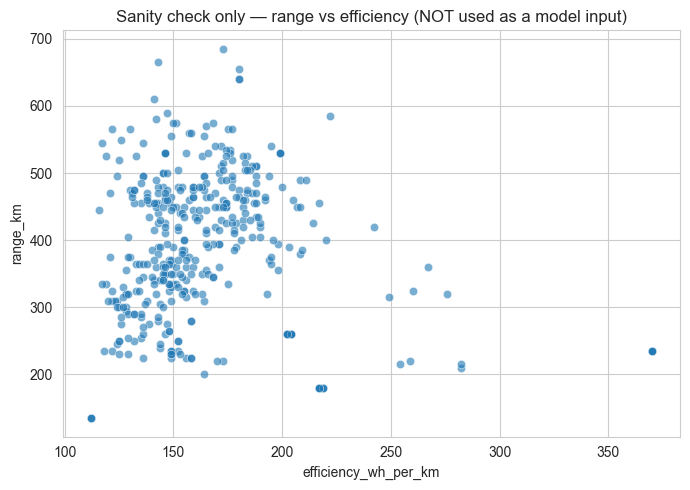

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=eda_df, x="efficiency_wh_per_km", y=TARGET, alpha=0.6)
plt.title("Sanity check only — range vs efficiency (NOT used as a model input)")
plt.tight_layout()
plt.show()


This plot is a training-data sanity check only. `efficiency_wh_per_km` is
excluded from every model input.


# 5. Feature Engineering

Beyond the raw columns, we derive a small set of specification-based features:

| Feature | Rationale |
|---|---|
| `footprint_m2` | length × width — a measure of overall vehicle size |
| `volume_m3` | footprint × height — bounding-box volume, not actual cabin volume |
| `battery_per_seat` | battery capacity normalised by seating capacity |
| `torque_per_100kwh` | torque normalised by battery capacity |
| `cells_missing_flag` | whether `number_of_cells` was reported |
| `cargo_missing_flag` | whether cargo volume in litres is available |
| `cargo_unknown_unit_flag` | whether cargo volume was recorded in banana boxes |

`number_of_cells` is kept with its missingness flag. Cleaning and feature
engineering are included in the final pipeline.


In [ ]:
def prepare_features(frame):
    if not isinstance(frame, pd.DataFrame) or not frame.columns.is_unique:
        raise ValueError("Pass a DataFrame with unique raw specification columns.")
    missing_columns = set(raw_feature_columns) - set(frame.columns)
    extra_columns = set(frame.columns) - set(raw_feature_columns)
    if missing_columns or extra_columns:
        raise ValueError(f"Missing columns: {sorted(missing_columns)}; extra columns: {sorted(extra_columns)}")

    features = clean_specifications(frame[raw_feature_columns])
    features["footprint_m2"] = (features["length_mm"] / 1000) * (features["width_mm"] / 1000)
    features["volume_m3"] = features["footprint_m2"] * (features["height_mm"] / 1000)
    features["battery_per_seat"] = features["battery_capacity_kWh"] / features["seats"]
    features["torque_per_100kwh"] = features["torque_nm"] / features["battery_capacity_kWh"] * 100
    if np.isinf(features.select_dtypes(include=np.number).to_numpy()).any():
        raise ValueError("Feature values are outside the supported numeric range.")
    return features


train_features = prepare_features(raw_df.loc[train_index, raw_feature_columns])
engineered_cols = ["footprint_m2", "volume_m3", "battery_per_seat", "torque_per_100kwh"]
train_features[engineered_cols].head()


,footprint_m2,volume_m3,battery_per_seat,torque_per_100kwh
0,6.181659,9.383758,9.45,621.693122
1,6.181659,9.383758,9.45,621.693122
2,7.448673,11.597584,10.16,679.133858
3,7.448673,11.597584,10.16,679.133858
4,8.728200,14.837940,12.00,516.666667


# 6. Train / Test Split & Preprocessing Pipeline

`brand`, `model` and `efficiency_wh_per_km` are excluded from `X`. The groups
set aside before EDA are reused here. Brand and the first model-name token
form a model-family proxy, keeping those related variants in the same group.

All learned preprocessing stays inside a `ColumnTransformer`. The pipeline
also applies the same cleaning and feature engineering to new raw inputs.


In [ ]:
drop_from_features = ["brand", "model", TARGET, LEAKAGE_COLUMN]
X = raw_df[raw_feature_columns].copy()
y = raw_df[TARGET].copy()

numeric_features = train_features.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = categorical_columns.copy()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test = X.loc[train_index].copy(), X.loc[test_index].copy()
y_train, y_test = y.loc[train_index].copy(), y.loc[test_index].copy()
groups_train = groups.loc[train_index]

assert set(X.columns).isdisjoint(drop_from_features)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Numeric features: ['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'length_mm', 'width_mm', 'height_mm', 'cells_missing_flag', 'cargo_missing_flag', 'cargo_unknown_unit_flag', 'footprint_m2', 'volume_m3', 'battery_per_seat', 'torque_per_100kwh']
Categorical features: ['drivetrain', 'segment', 'car_body_type']
Train: (391, 15), Test: (87, 15)


In [ ]:
feature_transformer = FunctionTransformer(
    joblib.wrap_non_picklable_objects(prepare_features), validate=False
)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown", keep_empty_features=True)),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])


# 7. Model Comparison

Given only 478 rows, we compare linear models, tree ensembles and gradient
boosting using 5-fold group cross-validation on the training set only.
A mean baseline provides a simple reference. Models are compared using
RMSE in kilometres — lower is better.


In [ ]:
models = {
    "Mean Baseline": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_SEED),
    "Lasso": Lasso(random_state=RANDOM_SEED, max_iter=10000),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_SEED, n_estimators=300, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_SEED),
    "XGBoost": XGBRegressor(
        random_state=RANDOM_SEED, n_estimators=300, objective="reg:squarederror", n_jobs=1
    ),
}

kfold = GroupKFold(n_splits=5)
cv_splits = list(kfold.split(X_train, y_train, groups_train))
pipelines = {}
cv_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("features", clone(feature_transformer)),
        ("preprocessor", clone(preprocessor)),
        ("model", clone(model)),
    ])
    pipelines[name] = pipe
    scores = cross_val_score(
        pipe, X_train, y_train, cv=cv_splits,
        scoring="neg_root_mean_squared_error", n_jobs=1, error_score="raise"
    )
    cv_results.append({"model": name, "cv_rmse_mean": -scores.mean(), "cv_rmse_std": scores.std()})

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_rmse_mean")
cv_results_df


,model,cv_rmse_mean,cv_rmse_std
2,Ridge,23.744368,2.725830
1,Linear Regression,24.918418,4.137492
3,Lasso,25.311500,2.281886
5,Gradient Boosting,31.514994,6.935639
4,Random Forest,34.948209,8.029631
6,XGBoost,36.466637,10.056583
0,Mean Baseline,104.575179,12.172069


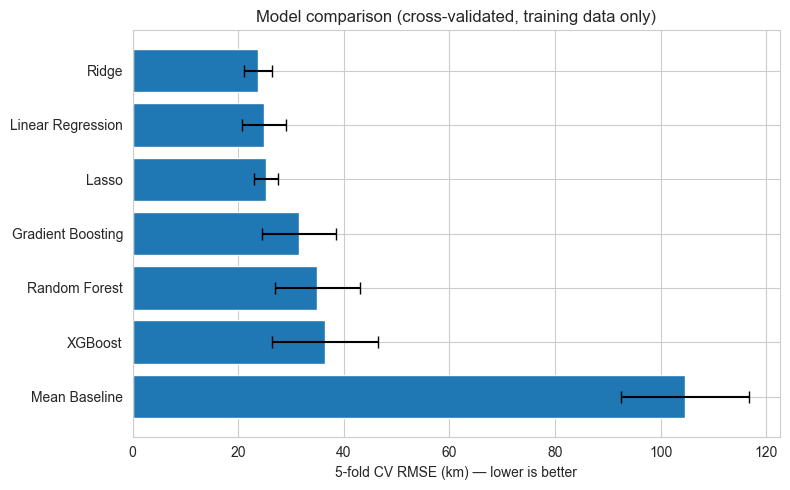

In [ ]:
plt.figure(figsize=(8, 5))
order = cv_results_df["model"]
bars = plt.barh(cv_results_df["model"], cv_results_df["cv_rmse_mean"],
               xerr=cv_results_df["cv_rmse_std"].values, capsize=4)
plt.xlabel("5-fold CV RMSE (km) — lower is better")
plt.title("Model comparison (cross-validated, training data only)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


The top two learned models are taken forward for tuning based on their
cross-validation RMSE. The final choice is also made using training CV
results, before evaluating the held-out test set.


# 8. Hyperparameter Tuning

In [ ]:
top_models = cv_results_df.loc[
    cv_results_df["model"] != "Mean Baseline", "model"
].head(2).tolist()

param_grids = {
    "Linear Regression": {},
    "Ridge": {"model__alpha": [0.1, 1, 5, 10, 20, 50, 100]},
    "Lasso": {"model__alpha": [0.01, 0.1, 1, 10]},
    "Random Forest": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 8, 16],
        "model__min_samples_leaf": [1, 3],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.03, 0.05, 0.1],
    },
    "XGBoost": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.03, 0.05, 0.1],
    },
}


In [ ]:
selection_scores = cv_results_df.set_index("model")["cv_rmse_mean"].to_dict()
model_candidates = {name: clone(pipe) for name, pipe in pipelines.items()}

for name in top_models:
    search = GridSearchCV(
        clone(pipelines[name]), param_grids[name], cv=cv_splits,
        scoring="neg_root_mean_squared_error", n_jobs=1, error_score="raise"
    )
    search.fit(X_train, y_train)
    print(f"{name} best params:", search.best_params_)
    print(f"{name} best CV RMSE:", -search.best_score_)
    if -search.best_score_ <= selection_scores[name]:
        selection_scores[name] = -search.best_score_
        model_candidates[name] = search.best_estimator_

FINAL_MODEL_NAME = min(selection_scores, key=selection_scores.get)
final_pipeline = clone(model_candidates[FINAL_MODEL_NAME])
final_pipeline.fit(X_train, y_train)
print("Final model:", FINAL_MODEL_NAME)


Ridge best params: {'model__alpha': 1}
Ridge best CV RMSE: 23.744368275940385
Linear Regression best params: {}
Linear Regression best CV RMSE: 24.918418180140783
Final model: Ridge


# 9. Final Evaluation on the Held-Out Test Set

The final model has already been selected using training cross-validation.
The test set is used here only to evaluate that fixed model and the mean
baseline.


In [ ]:
def evaluate(name, fitted_pipeline, X_eval, y_eval):
    preds = fitted_pipeline.predict(X_eval)
    mae = mean_absolute_error(y_eval, preds)
    rmse = mean_squared_error(y_eval, preds) ** 0.5
    r2 = r2_score(y_eval, preds)
    print(f"{name:>18s}  |  MAE: {mae:6.2f} km  |  RMSE: {rmse:6.2f} km  |  R2: {r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "predictions": preds}


final_test = evaluate(FINAL_MODEL_NAME, final_pipeline, X_test, y_test)
baseline_pipeline = clone(pipelines["Mean Baseline"]).fit(X_train, y_train)
baseline_test = evaluate("Mean Baseline", baseline_pipeline, X_test, y_test)


             Ridge  |  MAE:  19.19 km  |  RMSE:  23.61 km  |  R2: 0.9375
     Mean Baseline  |  MAE:  78.55 km  |  RMSE:  95.97 km  |  R2: -0.0319


In [ ]:
final_candidates = pd.DataFrame([
    {k: v for k, v in final_test.items() if k != "predictions"},
    {k: v for k, v in baseline_test.items() if k != "predictions"},
])
final_candidates


,model,MAE,RMSE,R2
0,Ridge,19.194570,23.614983,0.937513
1,Mean Baseline,78.549255,95.967267,-0.031947


**Model selection decision:** the model with the lowest training CV RMSE is
selected. The held-out MAE, RMSE and R² are reported for evaluation; they
are not used to change the model.


In [ ]:
final_predictions = final_test["predictions"]


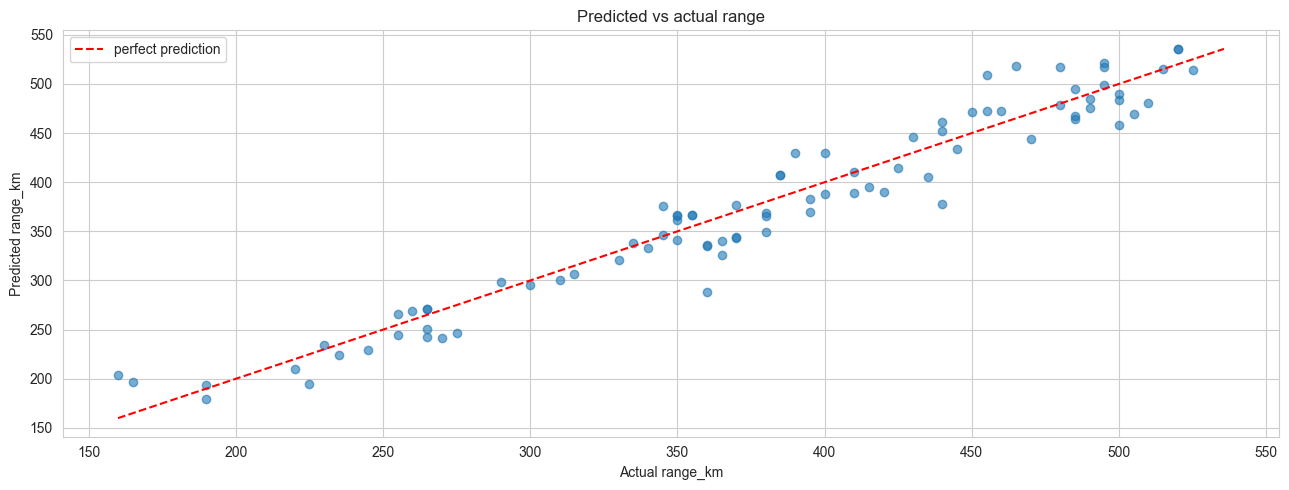

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(13, 5))

axes.scatter(y_test, final_predictions, alpha=0.6)
lims = [min(y_test.min(), final_predictions.min()), max(y_test.max(), final_predictions.max())]
axes.plot(lims, lims, "r--", label="perfect prediction")
axes.set_xlabel("Actual range_km")
axes.set_ylabel("Predicted range_km")
axes.set_title("Predicted vs actual range")
axes.legend()

plt.tight_layout()
plt.show()


- Feature Importance

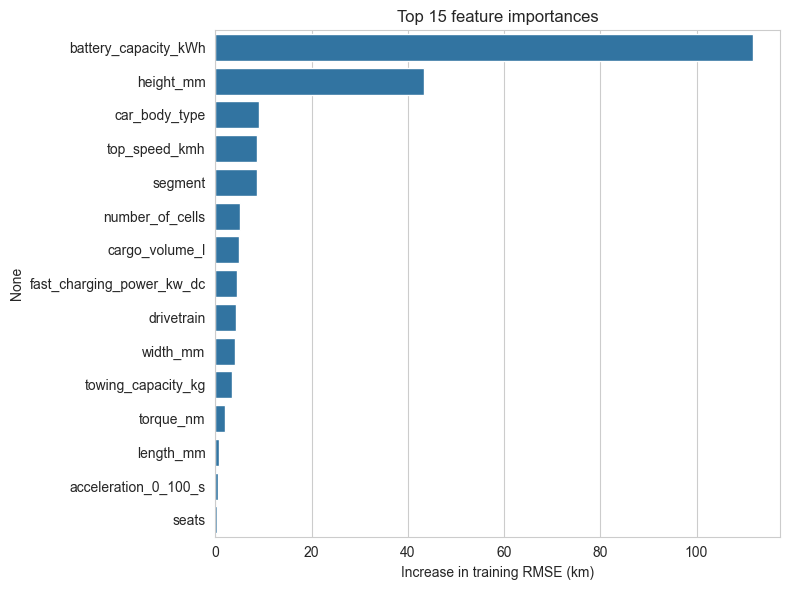

battery_capacity_kWh         111.759975
height_mm                     43.343488
car_body_type                  8.973599
top_speed_kmh                  8.680452
segment                        8.641800
number_of_cells                5.151314
cargo_volume_l                 4.829385
fast_charging_power_kw_dc      4.468010
drivetrain                     4.365588
width_mm                       4.049080
towing_capacity_kg             3.400261
torque_nm                      2.015296
length_mm                      0.661550
acceleration_0_100_s           0.547213
seats                          0.320207
dtype: float64

In [ ]:
feature_names_out = X_train.columns
importance_result = permutation_importance(
    final_pipeline, X_train, y_train, scoring="neg_root_mean_squared_error",
    n_repeats=5, random_state=RANDOM_SEED, n_jobs=1
)
importances = importance_result.importances_mean
importance_series = pd.Series(importances, index=feature_names_out).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importance_series.values, y=importance_series.index)
plt.title("Top 15 feature importances")
plt.xlabel("Increase in training RMSE (km)")
plt.tight_layout()
plt.show()
importance_series


Feature importance shows how shuffling each raw input changes training RMSE.
Larger increases suggest greater reliance on that input. Correlated features
can share importance; these values do not establish causality or held-out
performance.


# 10. Limitations

- The dataset is a **static specification sheet**: it has no trip-level
  telemetry, weather, HVAC load or battery-health measurements. The model
  predicts **dataset-listed range**, not range for a specific trip.
- `number_of_cells` is missing for ~42% of rows; imputed values and
  missingness flags may reflect catalogue reporting practices.
- Cargo entries in banana boxes have no supported conversion to litres.
- Model-family grouping is based on names; shared platforms and related
  vehicles with different names may still occur across groups.


# 11. Reproducible Pipeline — Save the Trained Artifact

The saved object is the **entire** `Pipeline` (cleaning + feature engineering +
preprocessing + model), so raw specification values go in and a range
prediction comes out. Only `ev_range_pipeline.joblib` is saved.


In [ ]:
MODEL_PATH = "../model/ev_range_pipeline.joblib"
joblib.dump(final_pipeline, MODEL_PATH, compress=3)
print(f"Saved trained pipeline to {MODEL_PATH}")

reloaded_pipeline = joblib.load(MODEL_PATH)
check_sample = X_train.iloc[[0]].copy()
np.testing.assert_allclose(
    reloaded_pipeline.predict(check_sample), final_pipeline.predict(check_sample)
)
print("Reloaded-model prediction:", reloaded_pipeline.predict(check_sample)[0])
print("Original-model prediction:", final_pipeline.predict(check_sample)[0])
print("Actual value:", y_train.iloc[0])


Saved trained pipeline to ../model/ev_range_pipeline.joblib
Reloaded-model prediction: 238.28536756494782
Original-model prediction: 238.28536756494782
Actual value: 225


# 12. Summary

| Objective | Result |
|---|---|
| Final model | Ridge |
| Test MAE | 19.19 |
| Test RMSE | 23.61 |
| Test R² | 93.75% |
| Leakage control | `efficiency_wh_per_km` excluded from all model inputs |
| Reproducibility | fixed `RANDOM_SEED = 42`; full pipeline saved to `ev_range_pipeline.joblib` |
